### Figure 2

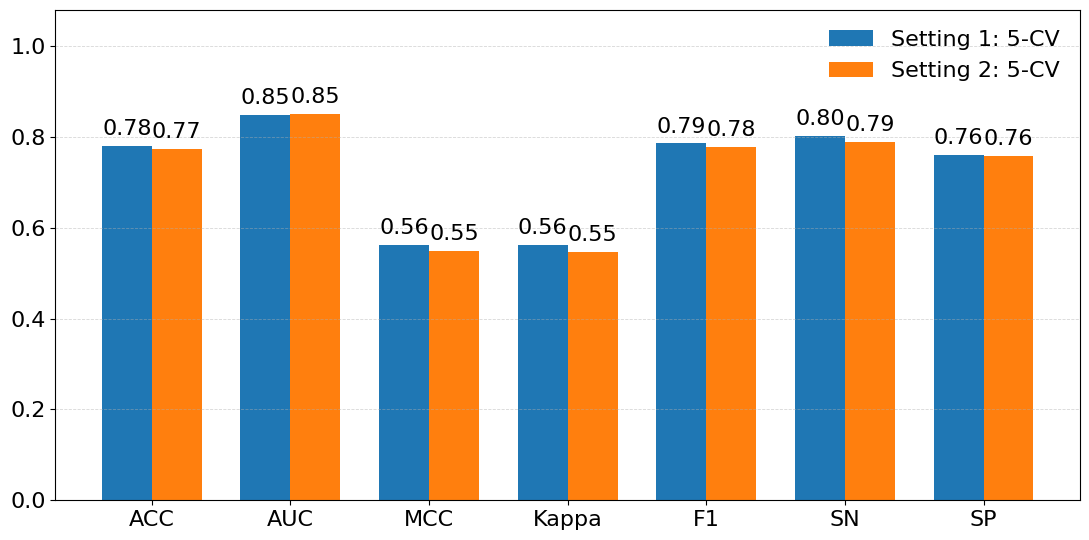

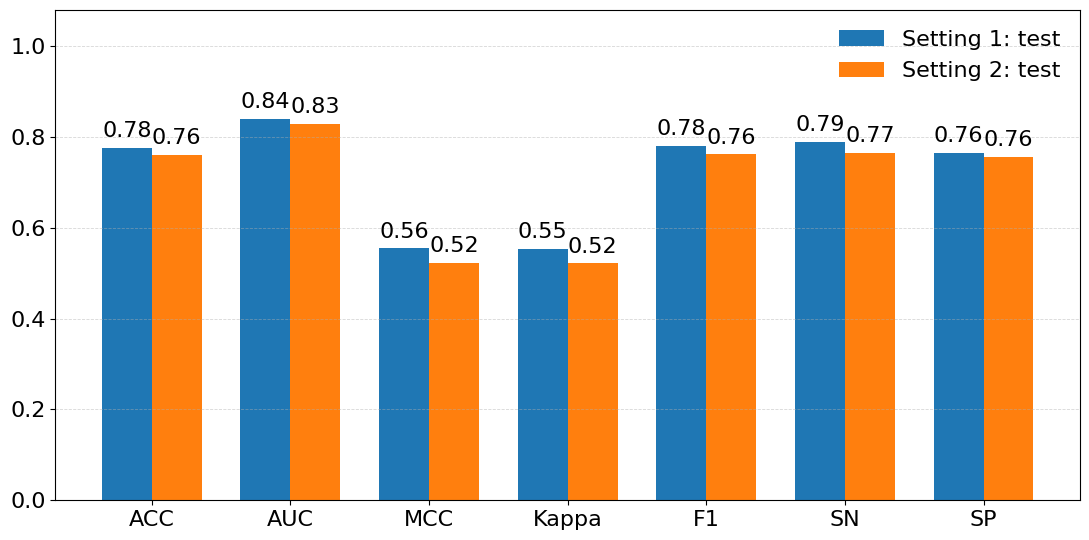

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ Data ------------------
data = [
    ["Setting 1: 5-CV",    78.11, 0.849, 0.563, 0.562, 80.23, 76.02, 0.786],
    ["Setting 1: test",         77.71, 0.840, 0.555, 0.554, 78.94, 76.48, 0.780],
    ["Setting 2: 5-CV",       77.42, 0.851, 0.549, 0.548, 79.02, 75.81, 0.778],
    ["Setting 2: test",76.12, 0.829, 0.523, 0.522, 76.53, 75.71, 0.762],
]
cols = ["Setting", "ACC", "AUC", "MCC", "Kappa", "SN", "SP", "F1"]
df = pd.DataFrame(data, columns=cols).set_index("Setting")

# convert percentages to fractions for unified 0-1 axis
df_plot = df.copy()
for c in ["ACC", "SN", "SP"]:
    df_plot[c] = df_plot[c] / 100.0

# metric order (SN/SP at end)
metrics = ["ACC", "AUC", "MCC", "Kappa", "F1", "SN", "SP"]

def plot_compare(settings, figsize=(11, 5.5)):
    x = np.arange(len(metrics))
    n = len(settings)
    width = 0.36 if n == 2 else 0.18

    fig, ax = plt.subplots(figsize=figsize)

    for i, s in enumerate(settings):
        y = df_plot.loc[s, metrics].to_numpy(dtype=float)
        xpos = x + (i - (n - 1) / 2) * width
        bars = ax.bar(xpos, y, width=width, label=s)

        # value labels
        for rect, val in zip(bars, y):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + 0.015,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylim(0, 1.08)
    ax.legend(frameon=False, fontsize=16)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.tight_layout()
    plt.show()

# ------------------ Two separate figures ------------------
plot_compare(["Setting 1: 5-CV", "Setting 2: 5-CV"])
plot_compare(["Setting 1: test", "Setting 2: test"])

### Figure 3A

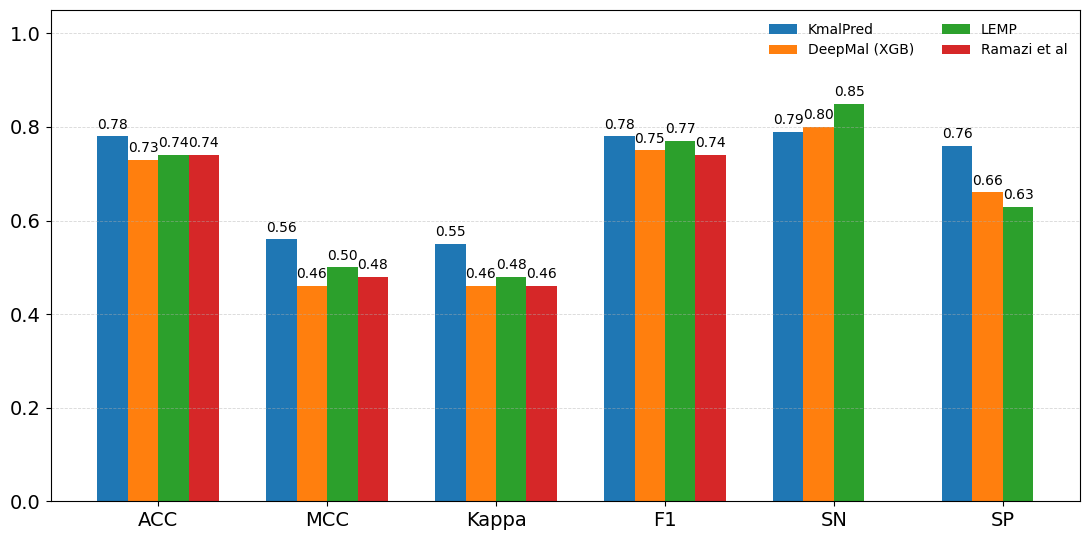

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data (metric order: BACC, MCC, F1, AUC, Sn, Sp)  <-- Sn/Sp at the end
methods = ["KmalPred","DeepMal (XGB)", "LEMP", "Ramazi et al" ]
metrics = ["ACC", "MCC", "Kappa", "F1", "SN", "SP"]

values = [[0.78, 0.56, 0.55, 0.78, 0.79, 0.76],
    [0.73, 0.46, 0.46, 0.75, 0.80, 0.66],          # DeepMal (XGB)
    [0.74, 0.50, 0.48, 0.77, 0.85, 0.63],          # LEMP
    [0.74, 0.48, 0.46, 0.74, np.nan, np.nan],      # Ramazi et al. hybrid
              # KmalPred
]

df = pd.DataFrame(values, index=methods, columns=metrics)

# Plot: grouped bar chart + value labels on top
x = np.arange(len(metrics))
n = len(methods)
width = 0.18

plt.figure(figsize=(11, 5.5))

for i, m in enumerate(methods):
    y = df.loc[m].to_numpy(dtype=float)
    xpos = x + (i - (n - 1) / 2) * width
    mask = ~np.isnan(y)

    bars = plt.bar(xpos[mask], y[mask], width=width, label=m)

    # Add numeric labels on top of bars
    for rect, val in zip(bars, y[mask]):
        plt.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.01,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, metrics, fontsize=14)  # <-- larger x-tick font
plt.yticks(fontsize=14)


plt.ylim(0, 1.05)
plt.legend(frameon=False, ncols=2, fontsize=10)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()


### Figure 3B

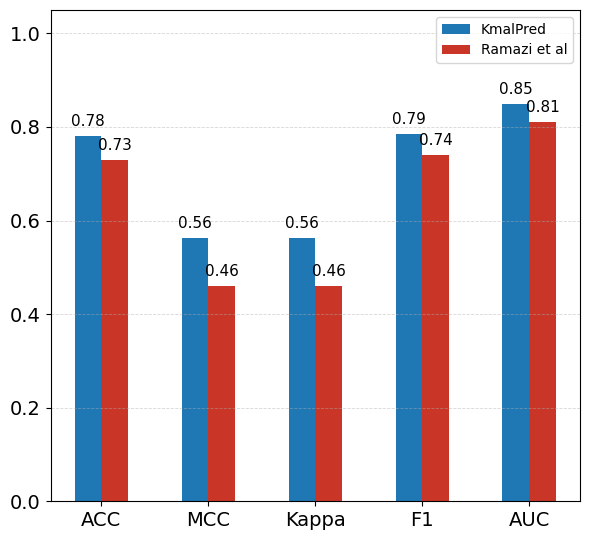

In [5]:
ours = {
    "ACC": 78.11 / 100,
    "MCC": 0.563,
    "Kappa": 0.562,
    "F1": 0.786,
    "AUC": 0.849,
}

paper = {
    "ACC": 0.73,
    "MCC": 0.46,
    "Kappa": 0.46,
    "F1": 0.74,
    "AUC": 0.81,
}

metrics = ["ACC", "MCC", "Kappa", "F1", "AUC"]

paper_vals = np.array([paper[m] for m in metrics], dtype=float)
ours_vals  = np.array([ours[m]  for m in metrics], dtype=float)

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 5.5))

# ours 在左边（前面），paper 在右边（后面）
bars_o = ax.bar(x - width/2, ours_vals,  width, label="KmalPred")
bars_p = ax.bar(x + width/2, paper_vals, width, label="Ramazi et al", color="#C93628")

def add_labels(bars, vals, dy=0.015):
    for rect, v in zip(bars, vals):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + dy,
                f"{v:.2f}",
                ha="center", va="bottom", fontsize=11)

add_labels(bars_o, ours_vals)
add_labels(bars_p, paper_vals)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 1.05)

ax.legend(frameon=True, fontsize=10)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()

### Figure 4

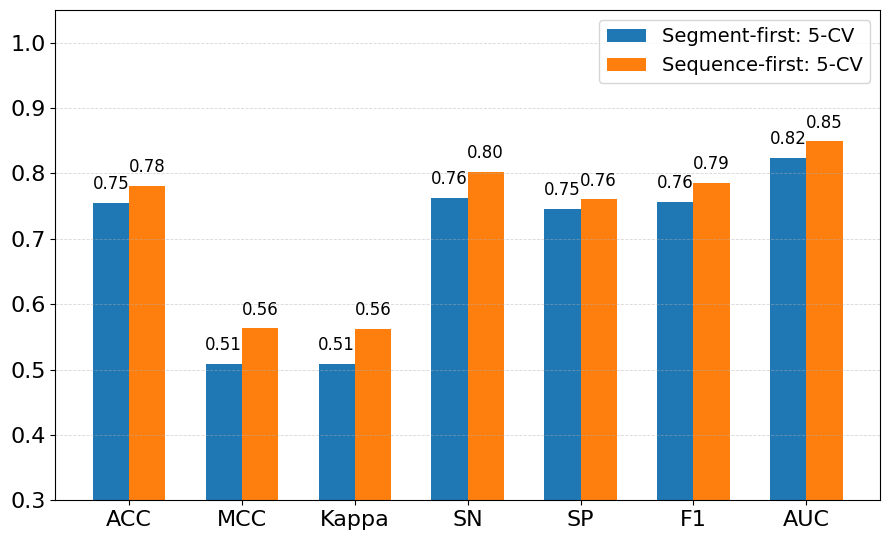

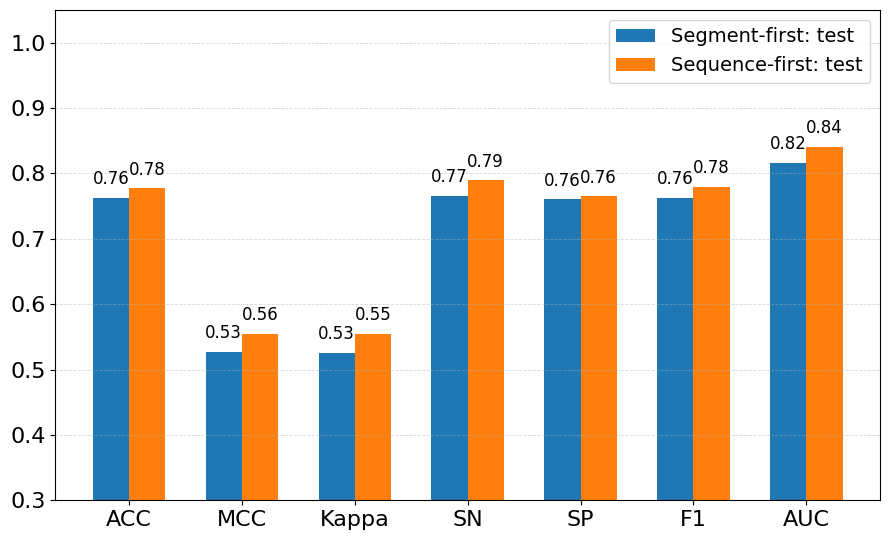

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Data (convert % -> 0-1 for ACC/Sn/Sp) ----------------
cv_segment = {"ACC": 75.44/100, "MCC": 0.509, "Kappa": 0.509, "SN": 76.22/100, "SP": 74.63/100, "F1": 0.756, "AUC": 0.824}
cv_seq     = {"ACC": 78.11/100, "MCC": 0.563, "Kappa": 0.562, "SN": 80.23/100, "SP": 76.02/100, "F1": 0.786, "AUC": 0.849}

ind_segment = {"ACC": 76.29/100, "MCC": 0.527, "Kappa": 0.526, "SN": 76.55/100, "SP": 76.02/100, "F1": 0.763, "AUC": 0.816}
ind_seq     = {"ACC": 77.71/100, "MCC": 0.555, "Kappa": 0.554, "SN": 78.94/100, "SP": 76.48/100, "F1": 0.780, "AUC": 0.840}

metrics = ["ACC", "MCC", "Kappa", "SN", "SP", "F1", "AUC"]

def plot_compare(d1, d2, label1, label2):
    v1 = np.array([d1[m] for m in metrics], dtype=float)
    v2 = np.array([d2[m] for m in metrics], dtype=float)

    x = np.arange(len(metrics))
    width = 0.32

    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars1 = ax.bar(x - width/2, v1, width, label=label1)
    bars2 = ax.bar(x + width/2, v2, width, label=label2)

    # value labels
    def add_labels(bars, vals, dy=0.015):
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + dy,
                    f"{v:.2f}",
                    ha="center", va="bottom", fontsize=12)

    add_labels(bars1, v1)
    add_labels(bars2, v2)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylim(0.3, 1.05)


    ax.legend(frameon=True, fontsize=14)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

    plt.tight_layout()
    plt.show()

# ---------------- Plot 1: 5CV ----------------
plot_compare(
    cv_segment, cv_seq,
    "Segment-first: 5-CV", "Sequence-first: 5-CV",
)

# ---------------- Plot 2: Independent ----------------
plot_compare(
    ind_segment, ind_seq,
    "Segment-first: test", "Sequence-first: test",
)



### Figure 5A

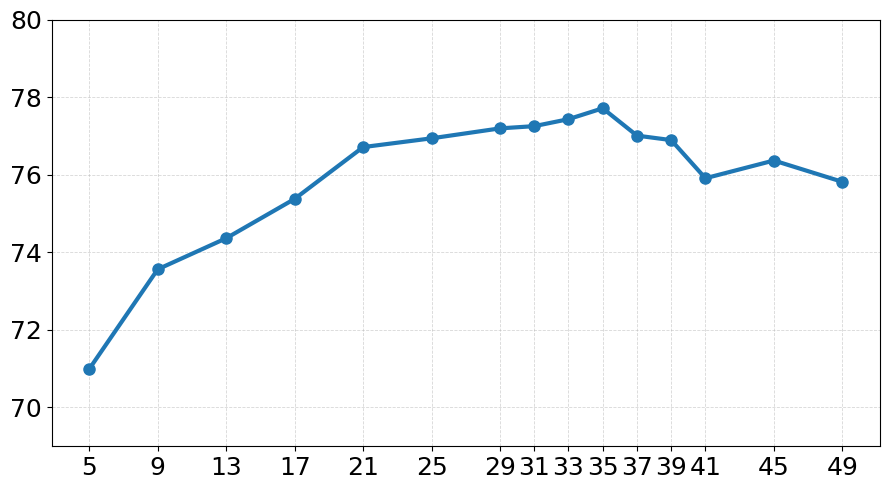

In [4]:
df = pd.read_excel("figure5_data.xlsx")
df.columns = [str(c).strip() for c in df.columns]

x = df["Window"]
acc_col = next(c for c in df.columns if c.replace(" ", "").lower() in ["acc(%)", "acc%","acc"])
acc = df[acc_col]

# 只画 ACC 曲线
plt.figure(figsize=(9, 5))
plt.plot(x, acc, marker="o", linewidth=3, markersize=8)
# plt.xlabel("Window length")
# plt.ylabel("ACC (%)")
plt.xticks(x, fontsize=18)   # x 轴刻度值变大
plt.yticks(fontsize=18)
plt.ylim(69, 80)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()


### Figure 5B

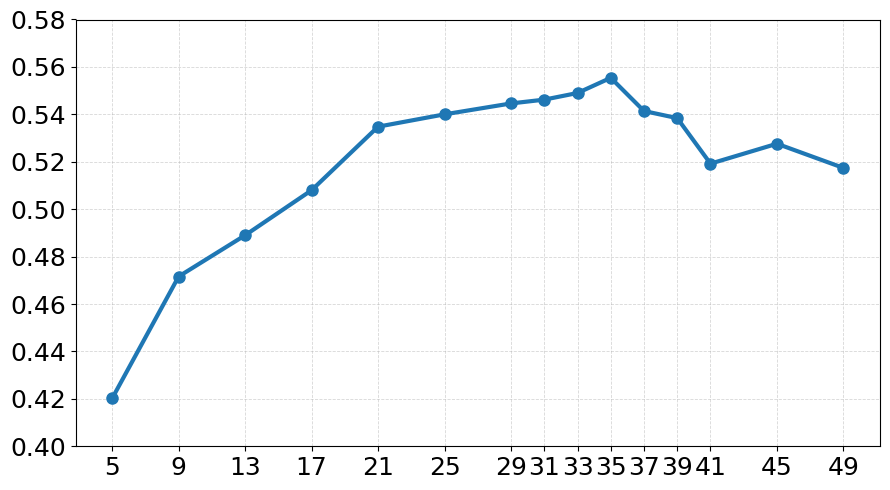

In [5]:
mcc_col = next(c for c in df.columns if c.replace(" ", "").lower() in ["mcc"])
mcc = df[mcc_col]

plt.figure(figsize=(9, 5))
plt.plot(x, mcc, marker="o", linewidth=3, markersize=8)

plt.xticks(x, fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(0.40, 0.58)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
plt.tight_layout()
plt.show()